Install & Import Libraries

In [1]:
# Install required libraries
!pip install pandas scikit-learn matplotlib seaborn

# Import everything we need
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully


Load All 3 Datasets

In [3]:
# Load the three structured log files
hdfs_df    = pd.read_csv(r'D:\Downloads\Capstone\NLP_Project\Dataset\Collected\HDFS_2k.log_structured.csv')
openssh_df = pd.read_csv(r'D:\Downloads\Capstone\NLP_Project\Dataset\Collected\Linux_2k.log_structured.csv')
linux_df   = pd.read_csv(r'D:\Downloads\Capstone\NLP_Project\Dataset\Collected\OpenSSH_2k.log_structured.csv')

# Check what columns each file has
print("HDFS columns:   ", list(hdfs_df.columns))
print("OpenSSH columns:", list(openssh_df.columns))
print("Linux columns:  ", list(linux_df.columns))

print(f"\nHDFS rows:    {len(hdfs_df)}")
print(f"OpenSSH rows: {len(openssh_df)}")
print(f"Linux rows:   {len(linux_df)}")

HDFS columns:    ['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'EventId', 'EventTemplate']
OpenSSH columns: ['LineId', 'Month', 'Date', 'Time', 'Level', 'Component', 'PID', 'Content', 'EventId', 'EventTemplate']
Linux columns:   ['LineId', 'Date', 'Day', 'Time', 'Component', 'Pid', 'Content', 'EventId', 'EventTemplate']

HDFS rows:    2000
OpenSSH rows: 2000
Linux rows:   2000


Preview Each Dataset

In [4]:
# See a sample of each dataset
print("=== HDFS Sample ===")
print(hdfs_df[['Content', 'EventId', 'EventTemplate']].head(3).to_string())

print("\n=== OpenSSH Sample ===")
print(openssh_df[['Content', 'EventId', 'EventTemplate']].head(3).to_string())

print("\n=== Linux Sample ===")
print(linux_df[['Content', 'EventId', 'EventTemplate']].head(3).to_string())

=== HDFS Sample ===
                                                                                                                     Content EventId                                                                             EventTemplate
0                                                              PacketResponder 1 for block blk_38865049064139660 terminating     E10                                         PacketResponder <*> for block blk_<*> terminating
1                                                           PacketResponder 0 for block blk_-6952295868487656571 terminating     E10                                         PacketResponder <*> for block blk_<*> terminating
2  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864      E6  BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>

=== OpenSSH Sample ===
                                                                

Combine All 3 Datasets Into One

In [5]:
# Extract only the columns we need from each dataset
hdfs_content    = hdfs_df[['Content', 'EventId', 'EventTemplate']].copy()
openssh_content = openssh_df[['Content', 'EventId', 'EventTemplate']].copy()
linux_content   = linux_df[['Content', 'EventId', 'EventTemplate']].copy()

# Add a source label so we know where each log came from
hdfs_content['source']    = 'HDFS'
openssh_content['source'] = 'OpenSSH'
linux_content['source']   = 'Linux'

# Combine all three into one single DataFrame
combined_df = pd.concat(
    [hdfs_content, openssh_content, linux_content],
    ignore_index=True
)

print(f"Total combined logs: {len(combined_df)}")
print("\nLogs per source:")
print(combined_df['source'].value_counts())
print("\nFirst 5 rows:")
combined_df.head()

Total combined logs: 6000

Logs per source:
source
HDFS       2000
OpenSSH    2000
Linux      2000
Name: count, dtype: int64

First 5 rows:


,Content,EventId,EventTemplate,source
0,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating,HDFS
1,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating,HDFS
2,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...,HDFS
3,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating,HDFS
4,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating,HDFS


Label the Data (Anomaly vs Normal)

In [6]:
# Define keywords that indicate suspicious or anomalous activity
anomaly_keywords = [
    'failed', 'failure', 'invalid', 'error', 'refused',
    'unauthorized', 'denied', 'attack', 'break-in',
    'illegal', 'bad', 'corrupt', 'lost', 'exception',
    'unknown', 'wrong', 'breach', 'suspicious',
    'timeout', 'abort', 'critical', 'fatal'
]

# Function to label each log entry
def label_log(content):
    if pd.isna(content):
        return 0
    content_lower = str(content).lower()
    for keyword in anomaly_keywords:
        if keyword in content_lower:
            return 1  # Anomaly
    return 0           # Normal

# Apply labeling to every row
combined_df['label'] = combined_df['Content'].apply(label_log)
combined_df['label_name'] = combined_df['label'].map({0: 'Normal', 1: 'Anomaly'})

print("Label distribution:")
print(combined_df['label_name'].value_counts())
print(f"\nAnomaly rate: {combined_df['label'].mean() * 100:.1f}%")

Label distribution:
label_name
Normal     3513
Anomaly    2487
Name: count, dtype: int64

Anomaly rate: 41.4%


Visualize Label Distribution

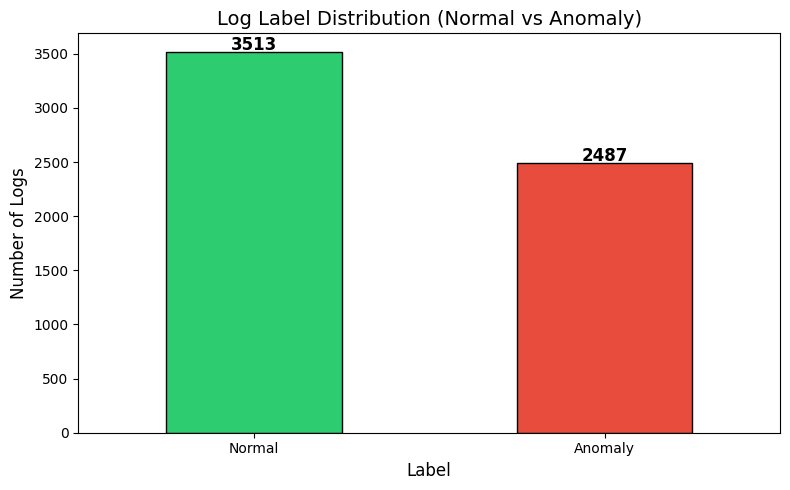

Chart saved!


In [7]:
# Bar chart of Normal vs Anomaly
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']

combined_df['label_name'].value_counts().plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title('Log Label Distribution (Normal vs Anomaly)', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Number of Logs', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(combined_df['label_name'].value_counts()):
    plt.text(i, v + 20, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

Visualize Distribution Per Source

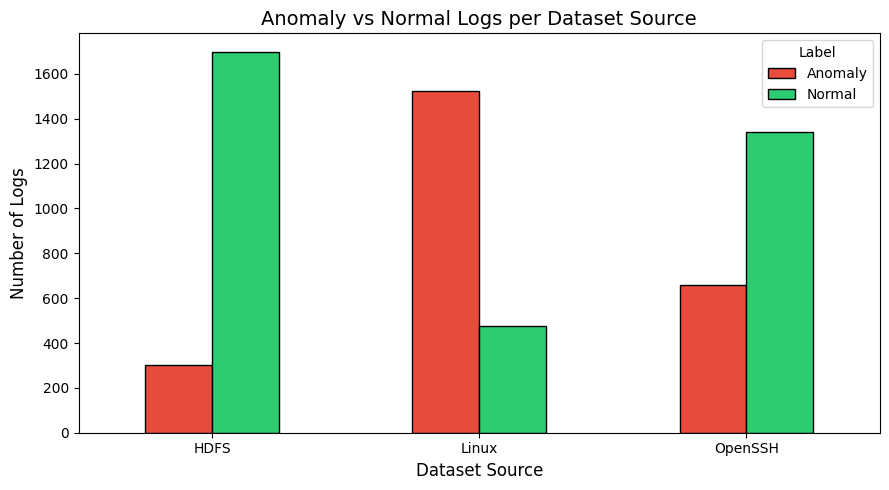

In [8]:
# Stacked bar chart - anomaly vs normal per dataset source
source_label = combined_df.groupby(['source', 'label_name']).size().unstack()

source_label.plot(
    kind='bar',
    color=['#e74c3c', '#2ecc71'],
    figsize=(9, 5),
    edgecolor='black'
)

plt.title('Anomaly vs Normal Logs per Dataset Source', fontsize=14)
plt.xlabel('Dataset Source', fontsize=12)
plt.ylabel('Number of Logs', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.tight_layout()
plt.savefig('source_distribution.png', dpi=150)
plt.show()

Clean and Normalize the Text

In [9]:
# Text cleaning function
def clean_log(text):
    if pd.isna(text):
        return ""
    text = str(text)

    # Replace IP addresses with a token
    text = re.sub(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', 'IP_ADDR', text)

    # Replace port numbers with a token
    text = re.sub(r'\bport\s+\d+', 'port PORT_NUM', text)

    # Replace HDFS block IDs with a token
    text = re.sub(r'blk_-?\d+', 'BLOCK_ID', text)

    # Remove process IDs like [24200]
    text = re.sub(r'\[\d+\]', '', text)

    # Replace hex values
    text = re.sub(r'0x[0-9a-fA-F]+', 'HEX_VAL', text)

    # Replace long standalone numbers
    text = re.sub(r'\b\d{5,}\b', 'NUM', text)

    # Replace domain/hostnames
    text = re.sub(r'\b[a-zA-Z0-9\-]+\.[a-zA-Z]{2,}\b', 'HOSTNAME', text)

    # Convert to lowercase
    text = text.lower()

    # Remove special characters (keep letters and spaces)
    text = re.sub(r'[^a-z\s_]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning to all logs
combined_df['cleaned_content'] = combined_df['Content'].apply(clean_log)

# Show before and after examples
print("BEFORE vs AFTER Cleaning Examples:\n")
examples = combined_df[['Content', 'cleaned_content', 'source']].sample(5, random_state=42)
for _, row in examples.iterrows():
    print(f"Source:  {row['source']}")
    print(f"BEFORE:  {row['Content']}")
    print(f"AFTER:   {row['cleaned_content']}")

BEFORE vs AFTER Cleaning Examples:

Source:  HDFS
BEFORE:  Received block blk_-4775386099844009890 of size 67108864 from /10.251.107.19
AFTER:   received block block_id of size num from ip_addr
Source:  OpenSSH
BEFORE:  0MB HIGHMEM available.
AFTER:   mb highmem available
Source:  HDFS
BEFORE:  Receiving block blk_-8227485321105019293 src: /10.251.195.33:56999 dest: /10.251.195.33:50010
AFTER:   receiving block block_id src ip_addr num dest ip_addr num
Source:  OpenSSH
BEFORE:  User unknown timed out after 900 seconds at Sat Jun 18 02:23:10 2005
AFTER:   user unknown timed out after seconds at sat jun
Source:  Linux
BEFORE:  Failed password for root from 183.62.140.253 port 55676 ssh2
AFTER:   failed password for root from ip_addr port port_num ssh


Check for Empty/Null Values After Cleaning

In [10]:
print("Null values check:")
print(combined_df[['Content', 'cleaned_content', 'label']].isnull().sum())

print(f"\nEmpty cleaned logs: {(combined_df['cleaned_content'] == '').sum()}")
print(f"Total usable logs:  {(combined_df['cleaned_content'] != '').sum()}")

# Drop any rows where cleaned content is empty
combined_df = combined_df[combined_df['cleaned_content'] != ''].reset_index(drop=True)
print(f"\nFinal dataset size after cleanup: {len(combined_df)} rows")

Null values check:
Content            0
cleaned_content    0
label              0
dtype: int64

Empty cleaned logs: 0
Total usable logs:  6000

Final dataset size after cleanup: 6000 rows


TF-IDF Vectorization

In [11]:
# Convert cleaned text into numerical features using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=2
)

# Fit and transform the cleaned text
X = vectorizer.fit_transform(combined_df['cleaned_content'])
y = combined_df['label']

print(f"TF-IDF Matrix Shape: {X.shape}")
print(f"  → {X.shape[0]} log entries")
print(f"  → {X.shape[1]} features (words/bigrams)")

# Show top features
feature_names = vectorizer.get_feature_names_out()
print(f"\nSample TF-IDF features (first 30):")
print(list(feature_names[:30]))

TF-IDF Matrix Shape: (6000, 500)
  → 6000 log entries
  → 500 features (words/bigrams)

Sample TF-IDF features (first 30):
['_m_', '_m_ part', '_r_', '_r_ part', '_task_', '_task_ _m_', '_task_ _r_', '_temporary', '_temporary _task_', 'abnormally', 'abnormally with', 'abort', 'acpi', 'added', 'added to', 'admin', 'admin from', 'admin preauth', 'alert', 'alert exited', 'anonymous', 'anonymous from', 'ask', 'ask ip_addr', 'at', 'at fri', 'at mon', 'at sat', 'at sun', 'at thu']


Save All Processed Files

In [12]:
# Save the full combined cleaned dataset
combined_df[['Content', 'cleaned_content', 'EventId',
             'EventTemplate', 'source', 'label', 'label_name']].to_csv(
    'cleaned_logs_combined.csv', index=False
)

# Save individual source files
for source in ['HDFS', 'OpenSSH', 'Linux']:
    subset = combined_df[combined_df['source'] == source]
    subset[['Content', 'cleaned_content', 'label', 'label_name']].to_csv(
        f'cleaned_{source.lower()}_logs.csv', index=False
    )
    print(f"Saved: cleaned_{source.lower()}_logs.csv ({len(subset)} rows)")

print("\nSaved: cleaned_logs_combined.csv")
print("All files saved successfully!")

Saved: cleaned_hdfs_logs.csv (2000 rows)
Saved: cleaned_openssh_logs.csv (2000 rows)
Saved: cleaned_linux_logs.csv (2000 rows)

Saved: cleaned_logs_combined.csv
All files saved successfully!


Isolation Forest

In [19]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
preds = iso_model.fit_predict(X)

combined_df['iso_pred'] = preds
combined_df['iso_anomaly'] = combined_df['iso_pred'].apply(lambda x: 1 if x == -1 else 0)

In [22]:
combined_df[['Content', 'iso_pred', 'iso_anomaly']].head(10)
print(combined_df[['Content', 'iso_pred', 'iso_anomaly']].head(10))
print(combined_df['iso_anomaly'].value_counts())

                                             Content  iso_pred  iso_anomaly
0  PacketResponder 1 for block blk_38865049064139...         1            0
1  PacketResponder 0 for block blk_-6952295868487...         1            0
2  BLOCK* NameSystem.addStoredBlock: blockMap upd...         1            0
3  PacketResponder 2 for block blk_82291938032499...         1            0
4  PacketResponder 2 for block blk_-6670958622368...         1            0
5  BLOCK* NameSystem.addStoredBlock: blockMap upd...         1            0
6  BLOCK* NameSystem.addStoredBlock: blockMap upd...         1            0
7  BLOCK* NameSystem.addStoredBlock: blockMap upd...         1            0
8  PacketResponder 2 for block blk_57249283928729...         1            0
9  Received block blk_3587508140051953248 of size...         1            0
iso_anomaly
0    5403
1     597
Name: count, dtype: int64


In [25]:
#print(combined_df.columns.tolist())
combined_df[combined_df['iso_anomaly'] == 1][['Content', 'cleaned_content']].head(30)

,Content,cleaned_content
15,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root rand _temporary _task...
18,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root rand _temporary _task...
27,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root rand _temporary _task...
57,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root rand _temporary _task...
58,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root rand _temporary _task...
72,Deleting block blk_1781953582842324563 file /m...,deleting block block_id file mnt hadoop dfs da...
184,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root randtxt _temporary _t...
186,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root randtxt _temporary _t...
200,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root randtxt _temporary _t...
203,BLOCK* NameSystem.allocateBlock: /user/root/ra...,block hostname user root randtxt _temporary _t...


LogBERT
pipeline using HDFS only

In [26]:
logbert_df = hdfs_df[['Content', 'EventId', 'EventTemplate']].copy()

In [27]:
print(logbert_df.shape)
print(logbert_df.columns.tolist())
logbert_df.head()

(2000, 3)
['Content', 'EventId', 'EventTemplate']


,Content,EventId,EventTemplate
0,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating
1,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating
2,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating
4,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating


In [28]:
logbert_df = logbert_df.dropna(subset=['EventId', 'EventTemplate', 'Content']).copy()
logbert_df = logbert_df.reset_index(drop=True)

print("Rows after cleaning:", len(logbert_df))
print("Unique EventIds:", logbert_df['EventId'].nunique())
logbert_df.head()

Rows after cleaning: 2000
Unique EventIds: 14


,Content,EventId,EventTemplate
0,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating
1,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating
2,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating
4,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating


In [29]:
# a simple token column for LogBERT
logbert_df['event_token'] = logbert_df['EventId'].astype(str)
logbert_df[['Content', 'EventId', 'event_token']].head()

,Content,EventId,event_token
0,PacketResponder 1 for block blk_38865049064139...,E10,E10
1,PacketResponder 0 for block blk_-6952295868487...,E10,E10
2,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,E6
3,PacketResponder 2 for block blk_82291938032499...,E10,E10
4,PacketResponder 2 for block blk_-6670958622368...,E10,E10


In [30]:
window_size = 20
step_size = 5

event_list = logbert_df['event_token'].tolist()

sequences = []
for i in range(0, len(event_list) - window_size + 1, step_size):
    window = event_list[i:i + window_size]
    sequences.append(window)

print("Total sequences:", len(sequences))
print("First sequence:", sequences[0])

# Convert each sequence into one line
sequence_lines = [' '.join(seq) for seq in sequences]

# Save to file
with open('hdfs_logbert_sequences.txt', 'w', encoding='utf-8') as f:
    for line in sequence_lines:
        f.write(line + '\n')

print("Saved: hdfs_logbert_sequences.txt")

Total sequences: 397
First sequence: ['E10', 'E10', 'E6', 'E10', 'E10', 'E6', 'E6', 'E6', 'E10', 'E11', 'E11', 'E13', 'E13', 'E6', 'E13', 'E7', 'E10', 'E11', 'E7', 'E6']
Saved: hdfs_logbert_sequences.txt


Step 1: split the sequences into train and test files

In [31]:
from sklearn.model_selection import train_test_split
import json

train_lines, test_lines = train_test_split(
    sequence_lines,
    test_size=0.2,
    random_state=42
)

with open('hdfs_train.txt', 'w', encoding='utf-8') as f:
    for line in train_lines:
        f.write(line + '\n')

with open('hdfs_test.txt', 'w', encoding='utf-8') as f:
    for line in test_lines:
        f.write(line + '\n')

unique_events = sorted(logbert_df['event_token'].unique())
event2idx = {event: idx + 1 for idx, event in enumerate(unique_events)}

with open('hdfs_event_vocab.json', 'w', encoding='utf-8') as f:
    json.dump(event2idx, f, indent=2)

print("Saved: hdfs_train.txt")
print("Saved: hdfs_test.txt")
print("Saved: hdfs_event_vocab.json")
print("Vocabulary size:", len(event2idx))

Saved: hdfs_train.txt
Saved: hdfs_test.txt
Saved: hdfs_event_vocab.json
Vocabulary size: 14


In [33]:
print(hdfs_df.columns.tolist())
print()
logbert_df.to_csv('hdfs_logbert_base.csv', index=False)
print("Saved: hdfs_logbert_base.csv")

['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'EventId', 'EventTemplate']

Saved: hdfs_logbert_base.csv


Train Test Split

In [34]:
from sklearn.model_selection import train_test_split
import json

train_lines, test_lines = train_test_split(
    sequence_lines,
    test_size=0.2,
    random_state=42
)

with open('hdfs_train.txt', 'w', encoding='utf-8') as f:
    for line in train_lines:
        f.write(line + '\n')

with open('hdfs_test.txt', 'w', encoding='utf-8') as f:
    for line in test_lines:
        f.write(line + '\n')

unique_events = sorted(logbert_df['event_token'].unique())
event2idx = {event: idx + 1 for idx, event in enumerate(unique_events)}

with open('hdfs_event_vocab.json', 'w', encoding='utf-8') as f:
    json.dump(event2idx, f, indent=2)

print("Saved: hdfs_train.txt")
print("Saved: hdfs_test.txt")
print("Saved: hdfs_event_vocab.json")
print("Vocabulary size:", len(event2idx))

Saved: hdfs_train.txt
Saved: hdfs_test.txt
Saved: hdfs_event_vocab.json
Vocabulary size: 14


In [35]:
logbert_df.to_csv('hdfs_logbert_base.csv', index=False)
print("Saved: hdfs_logbert_base.csv")

Saved: hdfs_logbert_base.csv


Parse cloud_auth.log

 Label cloud logs

Clean and normalize cloud logs (same pipeline as benchmark)

Merge with your existing benchmark data and save